In [5]:
import pandas as pd
d=pd.read_csv(r"XBRL-XBRL-PL-2025_part1.csv")


C:\Users\DELL\AppData\Local\Temp\ipykernel_15624\1972799807.py:2: DtypeWarning: Columns (0: TypeOfIndustry, 1: NatureReportStandaloneConsol) have mixed types. Specify dtype option on import or set low_memory=False.
  d=pd.read_csv(r"XBRL-XBRL-PL-2025_part1.csv")


In [6]:
print(d.isnull().sum().sum())
d.describe()

7001669


,Yearoffiling,RevenueFromSaleOfProducts,RevenueFromSaleOfServices,ExciseDuty,ServiceTaxCollected,OtherDutiesTaxesCollected,RevOpsOtherThanFinCo,RevenueFromInterest,RevFromOtherFinServ,RevOpsFinanceCo,...,AdministrativeExpEP,ResearchDevelopmentExpEP,PipelineOperationMaintenanceEP,OtherExpenditureEPActivities,ExceptionalItemsBeforeTax,ExtraordinaryItemsBeforeTax,PriorPeriodIncomeBeforeTax,PriorPeriodExpenseBeforeTax,PriorPeriodItemsBeforeTax,CSRExpenditure
count,96632.0,9.663200e+04,9.663200e+04,1.107500e+04,1.059000e+04,1.126400e+04,8.912900e+04,1.149000e+04,1.140300e+04,1.266300e+04,...,0.0,0.0,0.0,0.0,1.989000e+04,1.323600e+04,8.804000e+03,1.061600e+04,1.331100e+04,9.663200e+04
mean,2025.0,1.612854e+09,2.844400e+08,1.499348e+07,4.674708e+06,3.357029e+09,1.648542e+09,1.057629e+06,9.369106e+06,9.396516e+06,...,NaN,NaN,NaN,NaN,4.045459e+06,1.334490e+06,6.571266e+05,1.101214e+06,-4.436294e+05,7.001876e+05
std,0.0,1.205009e+11,1.940624e+09,3.119750e+08,5.955730e+07,3.535919e+11,5.718922e+09,2.264553e+07,5.154708e+08,4.896654e+08,...,NaN,NaN,NaN,NaN,3.688460e+08,1.352699e+08,7.979061e+07,2.805818e+07,6.562173e+07,2.607779e+06
min,2025.0,-2.304329e+07,-3.577850e+08,-4.325192e+08,-6.880150e+08,-6.781700e+08,-5.019867e+08,-1.000000e+01,-2.858000e+06,-2.858000e+06,...,NaN,NaN,NaN,NaN,-1.169117e+10,-9.659343e+09,-3.206480e+09,-5.021258e+08,-3.206480e+09,0.000000e+00
25%,2025.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.989044e+07,0.000000e+00,0.000000e+00,0.000000e+00,...,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2025.0,1.828805e+08,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,8.676330e+08,0.000000e+00,0.000000e+00,0.000000e+00,...,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,2025.0,1.330914e+09,3.800050e+07,0.000000e+00,0.000000e+00,0.000000e+00,1.758990e+09,0.000000e+00,0.000000e+00,0.000000e+00,...,NaN,NaN,NaN,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,2025.0,3.742558e+13,1.622078e+11,1.575435e+10,1.558935e+09,3.752743e+13,4.451788e+11,1.278246e+09,3.971197e+10,3.971197e+10,...,NaN,NaN,NaN,NaN,2.833384e+10,7.133500e+09,4.998547e+09,1.629144e+09,4.998547e+09,3.217760e+08


In [7]:
print("Rows:", d.shape[0])
print("Columns:", d.shape[1])
print("Total cells:", d.size)
print("Total NULLs:", d.isnull().sum().sum())

Rows: 96632
Columns: 130
Total cells: 12562160
Total NULLs: 7001669


In [8]:
nulls = d.isnull().sum()

print(nulls[nulls > 0].sort_values(ascending=False))

ExpProductionTransportOtherEP     96632
ExtractionCostEPActivities        96632
CessPertainingEPActivities        96632
OtherExpenditureEPActivities      96632
PipelineOperationMaintenanceEP    96632
                                  ...  
OtherNonOperatingIncome           10590
CurrentTax                        10215
DepreciationExpense               10081
RevOpsOtherThanFinCo               7503
OtherExpenses                       287
Length: 92, dtype: int64


In [9]:
# ==============================
# DATA QUALITY CHECK
# ==============================

print("========== DATASET OVERVIEW ==========")

print("Rows:", d.shape[0])
print("Columns:", d.shape[1])
print("Total Cells:", d.size)

print("\n========== MISSING VALUES ==========")

missing_report = pd.DataFrame({
    "Missing Count": d.isnull().sum(),
    "Missing %": (d.isnull().sum() / len(d) * 100).round(2),
    "Data Type": d.dtypes
})

print(missing_report.sort_values("Missing %", ascending=False))

print("\n========== COMPLETELY EMPTY COLUMNS ==========")

empty_columns = d.columns[d.isnull().all()]

print("Number of completely empty columns:", len(empty_columns))
print(empty_columns.tolist())

print("\n========== DUPLICATE ROWS ==========")

print("Duplicate rows:", d.duplicated().sum())

print("\n========== CONSTANT COLUMNS ==========")

constant_columns = [
    col for col in d.columns
    if d[col].nunique(dropna=False) <= 1
]

print("Number of constant columns:", len(constant_columns))
print(constant_columns)

print("\n========== DATA TYPES ==========")

print(d.dtypes.value_counts())

print("\n========== TOTAL NULL VALUES ==========")

print(d.isnull().sum().sum())

print("\n========== NULL PERCENTAGE ==========")

null_percentage = (d.isnull().sum().sum() / d.size) * 100

print(round(null_percentage, 2), "%")

========== DATASET OVERVIEW ==========
Rows: 96632
Columns: 130
Total Cells: 12562160

========== MISSING VALUES ==========
                                  Missing Count  Missing % Data Type
InterestAndIncomeTaxRefund                96632      100.0   float64
ExpProductionTransportOtherEP             96632      100.0   float64
ResearchDevelopmentExpEP                  96632      100.0   float64
AdministrativeExpEP                       96632      100.0   float64
ExtractionCostEPActivities                96632      100.0   float64
...                                         ...        ...       ...
MiscExpenditureWrittenOff                     0        0.0   float64
ProvisionBadDoubtfulDebtsCreated              0        0.0   float64
DateStartReportingPeriod                      0        0.0       str
DateEndReportingPeriod                        0        0.0       str
CSRExpenditure                                0        0.0   float64

[130 rows x 3 columns]

========== COMPLETELY E

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns


<Axes: xlabel='Revenue', ylabel='Count'>

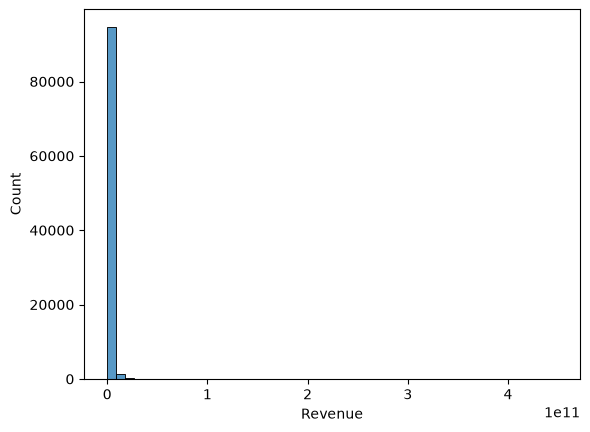

In [11]:
sns.histplot(data=d["Revenue"].dropna(), bins=50)